# TFM — EDA I: Análisis a nivel persona
**Autora:** Meritxell Abellan Collado  
**Dataset:** Accidentes de tráfico en Madrid (Open Data Ayuntamiento de Madrid)  

---

## Objetivo de este notebook

Este notebook realiza el análisis exploratorio del dataset en su estructura original: **un registro por persona implicada**. Se describen la calidad de los datos, la distribución de la variable `LESIVIDAD` y el perfil de los implicados (sexo, edad, tipo de persona y vehículo).  

El análisis orientado al modelo —tras la agregación a nivel accidente— se encuentra en `02_EDA_accidentes.ipynb`.

---
## 0. Carga de librerías y datos

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.stats import chi2_contingency, kstest
import warnings

warnings.filterwarnings('ignore')

# Estilo global de gráficos
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100

# Paleta de colores global para lesividad
COLOR_SIN_DATO       = '#bdc3c7'
COLORES_LESIVIDAD    = {'IL': '#2ecc71', 'HL': '#f1c40f', 'HG': '#e67e22', 'MT': '#e74c3c'}
ORDEN_LESIVIDAD      = ['IL', 'HL', 'HG', 'MT']
ORDEN_LESIVIDAD_EXT  = ORDEN_LESIVIDAD + ['Sin dato']
COLORES_LESIVIDAD_EXT = {**COLORES_LESIVIDAD, 'Sin dato': COLOR_SIN_DATO}
LABELS_LESIVIDAD_EXT = ['Ileso', 'Herido leve', 'Herido grave', 'Fallecido', 'Sin dato']

print('Librerías y constantes cargadas correctamente.')

Librerías y constantes cargadas correctamente.


In [53]:
# Carga del dataset
DATA_PATH = '../data/raw/accidentes-trafico.xlsx'

df = pd.read_excel(DATA_PATH)

print(f'Dataset cargado: {df.shape[0]:,} filas | {df.shape[1]} columnas')

Dataset cargado: 199,078 filas | 26 columnas


El dataset incluye registros de testigos, que no están directamente implicados en los accidentes y que pueden distorsionar el estudio. Por ello, se suprimen de manera que solo se tienen en consideración los implicados directos en cada accidente.

Además, los **valores centinela** (`'NO ASIGNADO'`, `'DESCONOCIDO'`...) se convierten a `NaN` para que el análisis de nulos los capture correctamente.

> Las transformaciones formales (encoding, imputación, train/test split) se documentan en el notebook de preprocesado.

In [63]:
# Exclusión de testigos
df['TIPO PERSONA'] = df['TIPO PERSONA'].str.strip()
n_testigos = (df['TIPO PERSONA'] == 'TESTIGO').sum()
df = df[df['TIPO PERSONA'] != 'TESTIGO'].copy()

# Conversión de fecha
df['FECHA'] = pd.to_datetime(df['FECHA'])
df['AÑO']  = df['FECHA'].dt.year
df['MES']  = df['FECHA'].dt.month

# Limpieza de columnas de texto (strip)
for col in df.select_dtypes('object').columns:
    df[col] = df[col].str.strip()

# Valores centinela → NaN
VALORES_NULOS = {'NO ASIGNADO', 'NO ASIGNADA', 'DESCONOCIDO', 'DESCONOCIDA'}
for col in df.select_dtypes('object').columns:
    df[col] = df[col].replace(VALORES_NULOS, pd.NA)

print(f'Registros originales:         {len(df) + n_testigos:>8,}')
print(f'Testigos excluidos:           {n_testigos:>8,}')
print(f'Registros nivel persona (df): {len(df):>8,}')
print(f'Accidentes únicos:            {df["Nº PARTE"].nunique():>8,}')

Registros originales:          174,353
Testigos excluidos:                  0
Registros nivel persona (df):  174,353
Accidentes únicos:              68,773


---
## 1. Entendimiento del dataset

Antes de cualquier análisis, es fundamental entender qué contiene el dataset: qué representa cada columna, cuántos registros hay, qué tipos de datos se usan y si existen valores nulos o inconsistentes.

El dataset recoge información a nivel persona: para cada accidente (`Nº PARTE`) puede haber varias filas, una por cada persona implicada (conductor, peatón, viajero, testigo). Las variables se pueden agrupar en:
- **Identificación:** `Nº PARTE`, `Nº`, `FECHA`
- **Tiempo:** `RANGO HORARIO`, `DIA SEMANA`
- **Lugar:** `DISTRITO`, `LUGAR ACCIDENTE`
- **Condiciones atmosféricas:** columnas `CPFA_*`
- **Estado del firme:** columnas `CPSV_*`
- **Accidente:** `TIPO ACCIDENTE`, `Nº VICTIMAS *`
- **Persona:** `Tipo Vehiculo`, `TIPO PERSONA`, `SEXO`, `Tramo Edad`
- **Variable objetivo:** `LESIVIDAD`

In [56]:
# Primeras filas
df.head()

,FECHA,RANGO HORARIO,DIA SEMANA,DISTRITO,LUGAR ACCIDENTE,Nº,Nº PARTE,CPFA Granizo,CPFA Hielo,CPFA Lluvia,...,CPSV Seca Y Limpia,Nº VICTIMAS *,TIPO ACCIDENTE,Tipo Vehiculo,TIPO PERSONA,SEXO,LESIVIDAD,Tramo Edad,AÑO,MES
0,2012-01-01,DE 2:00 A 2:59,DOMINGO,CENTRO,CALLE DE LA PRINCESA NUM,10.0,2012/98,NO,NO,NO,...,SI,2,ATROPELLO,NaN,PEATON,HOMBRE,HL,DE 25 A 29 AÑOS,2012,1
1,2012-01-01,DE 2:00 A 2:59,DOMINGO,CENTRO,CALLE DE LA PRINCESA NUM,10.0,2012/98,NO,NO,NO,...,SI,2,ATROPELLO,NaN,PEATON,MUJER,HL,DE 25 A 29 AÑOS,2012,1
3,2012-01-01,DE 2:00 A 2:59,DOMINGO,CENTRO,CALLE DE LA PRINCESA NUM,10.0,2012/98,NO,NO,NO,...,SI,2,ATROPELLO,AUTO-TAXI,CONDUCTOR,HOMBRE,IL,DE 35 A 39 AÑOS,2012,1
4,2012-01-01,DE 2:00 A 2:59,DOMINGO,PUENTE DE VALLECAS,AVENIDA DE SAN DIEGO NUM,96.0,2012/118,NO,NO,NO,...,SI,1,OTRAS CAUSAS,TURISMO,CONDUCTOR,HOMBRE,IL,DE 25 A 29 AÑOS,2012,1
5,2012-01-01,DE 2:00 A 2:59,DOMINGO,PUENTE DE VALLECAS,AVENIDA DE SAN DIEGO NUM,96.0,2012/118,NO,NO,NO,...,SI,1,OTRAS CAUSAS,TURISMO,CONDUCTOR,HOMBRE,IL,DE 35 A 39 AÑOS,2012,1


In [57]:
# Resumen descriptivo adaptado al tipo de variable
import pandas.api.types as pat

resumen = []
for col in df.columns:
    info = {
        'Variable':  col,
        'Tipo':      str(df[col].dtype),
        'No nulos':  df[col].notna().sum(),
        'Nulos (%)': round(df[col].isnull().mean() * 100, 2),
        'Únicos':    df[col].nunique(),
        'Valor más frecuente':     pd.NA,
        'Frec. más frecuente (%)': pd.NA,
        'Media':   pd.NA,
        'Mediana': pd.NA,
        'Std':     pd.NA,
    }
    if pat.is_string_dtype(df[col]) or pat.is_object_dtype(df[col]):
        moda = df[col].value_counts()
        info['Valor más frecuente']     = moda.idxmax() if not moda.empty else pd.NA
        info['Frec. más frecuente (%)'] = round(moda.max() / moda.sum() * 100, 2) if not moda.empty else pd.NA
    elif pat.is_numeric_dtype(df[col]):
        moda = df[col].mode()
        info['Valor más frecuente']     = moda[0] if not moda.empty else pd.NA
        info['Frec. más frecuente (%)'] = round((df[col] == moda[0]).mean() * 100, 2) if not moda.empty else pd.NA
        info['Media']   = round(df[col].mean(), 2)
        info['Mediana'] = round(df[col].median(), 2)
        info['Std']     = round(df[col].std(), 2)
    # datetime → se omiten estadísticos numéricos (ya visible en df.info())
    elif pat.is_datetime64_any_dtype(df[col]):
        moda = df[col].mode()
        info['Valor más frecuente']     = moda[0].date() if not moda.empty else pd.NA
        info['Frec. más frecuente (%)'] = round((df[col] == moda[0]).mean() * 100, 2) if not moda.empty else pd.NA
    resumen.append(info)

pd.DataFrame(resumen).set_index('Variable')

,Tipo,No nulos,Nulos (%),Únicos,Valor más frecuente,Frec. más frecuente (%),Media,Mediana,Std
Variable,,,,,,,,,
FECHA,datetime64[us],174353,0.00,2557,2013-10-25,0.11,<NA>,<NA>,<NA>
RANGO HORARIO,str,174353,0.00,24,DE 14:00 A 14:59,7.39,<NA>,<NA>,<NA>
DIA SEMANA,str,174353,0.00,7,VIERNES,17.13,<NA>,<NA>,<NA>
DISTRITO,str,174353,0.00,21,SALAMANCA,7.55,<NA>,<NA>,<NA>
LUGAR ACCIDENTE,str,174353,0.00,13958,AUTOVIA M-30 CALZADA 1 KM.,3.42,<NA>,<NA>,<NA>
Nº,float64,171680,1.53,862,0.0,47.37,1039.17,1.0,4052.98
Nº PARTE,str,174353,0.00,68773,2012/11769,0.02,<NA>,<NA>,<NA>
CPFA Granizo,str,174353,0.00,2,NO,99.99,<NA>,<NA>,<NA>
CPFA Hielo,str,174353,0.00,2,NO,99.95,<NA>,<NA>,<NA>


In [58]:
# Número de accidentes únicos
n_accidentes = df['Nº PARTE'].nunique()
n_personas   = len(df)
print(f'Registros totales (nivel persona): {n_personas:,}')
print(f'Accidentes únicos (nivel accidente): {n_accidentes:,}')
print(f'Media de personas implicadas por accidente: {n_personas / n_accidentes:.2f} (incluyendo ilesos)')

Registros totales (nivel persona): 174,353
Accidentes únicos (nivel accidente): 68,773
Media de personas implicadas por accidente: 2.54 (incluyendo ilesos)


In [59]:
# Duplicados exactos (todas las columnas)
duplicados = df.duplicated().sum()
print(f'Filas duplicadas exactas: {duplicados:,}')

# Duplicados por campos clave (misma persona en el mismo accidente)
duplicados_clave = df.duplicated(subset=['Nº PARTE', 'TIPO PERSONA', 'SEXO', 'Tramo Edad', 'LESIVIDAD']).sum()
print(f'Posibles duplicados por campos clave: {duplicados_clave:,}')

Filas duplicadas exactas: 4,065
Posibles duplicados por campos clave: 4,766


In [60]:
# Rango temporal del dataset
print(f'Desde: {df["FECHA"].min().date()}')
print(f'Hasta: {df["FECHA"].max().date()}')
print(f'Años cubiertos: {sorted(df["FECHA"].dt.year.unique())}')

Desde: 2012-01-01
Hasta: 2018-12-31
Años cubiertos: [np.int32(2012), np.int32(2013), np.int32(2014), np.int32(2015), np.int32(2016), np.int32(2017), np.int32(2018)]


In [61]:
# Valores únicos por columna categórica
cols_categoricas = df.select_dtypes(include='object').columns
for col in cols_categoricas:
    valores = df[col].unique()
    print(f'\n{col} ({len(valores)} valores únicos):')
    print(sorted([str(v) for v in valores]))


RANGO HORARIO (24 valores únicos):
['DE 00:00 A 00:59', 'DE 10:00 A 10:59', 'DE 11:00 A 11:59', 'DE 12:00 A 12:59', 'DE 13:00 A 13:59', 'DE 14:00 A 14:59', 'DE 15:00 A 15:59', 'DE 16:00 A 16:59', 'DE 17:00 A 17:59', 'DE 18:00 A 18:59', 'DE 19:00 A 19:59', 'DE 1:00 A 1:59', 'DE 20:00 A 20:59', 'DE 21:00 A 21:59', 'DE 22:00 A 22:59', 'DE 23:00 A 23:59', 'DE 2:00 A 2:59', 'DE 3:00 A 3:59', 'DE 4:00 A 4:59', 'DE 5:00 A 5:59', 'DE 6:00 A 6:59', 'DE 7:00 A 7:59', 'DE 8:00 A 8:59', 'DE 9:00 A 9:59']

DIA SEMANA (7 valores únicos):
['DOMINGO', 'JUEVES', 'LUNES', 'MARTES', 'MIERCOLES', 'SABADO', 'VIERNES']

DISTRITO (21 valores únicos):
['ARGANZUELA', 'BARAJAS', 'CARABANCHEL', 'CENTRO', 'CHAMARTIN', 'CHAMBERI', 'CIUDAD LINEAL', 'FUENCARRAL-EL PARDO', 'HORTALEZA', 'LATINA', 'MONCLOA-ARAVACA', 'MORATALAZ', 'PUENTE DE VALLECAS', 'RETIRO', 'SALAMANCA', 'SAN BLAS', 'TETUAN', 'USERA', 'VICALVARO', 'VILLA DE VALLECAS', 'VILLAVERDE']

LUGAR ACCIDENTE (13958 valores únicos):
['ACCESO  M-40 SALIDA AVDA.

In [64]:
# Análisis de valores nulos
nulos     = df.isnull().sum()
nulos_pct = (nulos / len(df) * 100).round(2)
nulos_df  = pd.DataFrame({'Nulos': nulos, 'Porcentaje (%)': nulos_pct})
nulos_df  = nulos_df[nulos_df['Nulos'] > 0].sort_values('Nulos', ascending=False)

if nulos_df.empty:
    print('No hay valores nulos en el dataset.')
else:
    print(nulos_df)

               Nulos  Porcentaje (%)
Tipo Vehiculo  11763            6.75
Tramo Edad      9616            5.52
LESIVIDAD       7860            4.51
SEXO            7665            4.40
Nº              2673            1.53


### 📝 Resumen — Sección 1

> - El dataset contiene 199.078 registros a nivel persona, correspondientes a 68.773 accidentes únicos. Tras excluir los testigos, trabajamos con 174.353 registros de personas, manteniendo los mismos accidentes.
> - Hay 4.065 filas duplicadas exactas y 4.766 posibles duplicados por campos clave (mismo perfil de víctima en el mismo accidente). Se abordarán en la fase de preprocesado.
> - De media, cada accidente cuenta con 2,54 personas implicadas (incluyendo heridos, fallecidos e ilesos)
> - El dataset cubre el período entre el 1 de enero de 2012 y el 31 de diciembre de 2018 en los 21 distritos de Madrid.
> - Únicamente la columna `Nº` (número de la dirección o kilómetro de la vía) presenta valores nulos, correspondientes a accidentes ocurridos en cruces.
> - El dataset tiene 26 columnas: 25 categóricas y 1 numérica (`Nº VICTIMAS *`).

---
## 2. Variable objetivo: LESIVIDAD

La variable `LESIVIDAD` recoge el grado de lesión de cada persona implicada en un accidente. Es la base para construir la variable objetivo del modelo.

Los valores son:
- **IL** — Ileso (sin lesiones)
- **HL** — Herido leve
- **HG** — Herido grave
- **MT** — Fallecido
- **NO ASIGNADA** — Sin clasificar (se tratará en preprocesado)

En esta sección se analiza la distribución de `LESIVIDAD` a nivel persona, y se razona cómo se derivará la variable objetivo a nivel accidente, que será la máxima lesividad entre todos los implicados.

In [66]:
# Distribución absoluta y relativa de LESIVIDAD
lesividad_dist = df['LESIVIDAD'].value_counts(dropna=False)
lesividad_pct  = df['LESIVIDAD'].value_counts(normalize=True, dropna=False) * 100
lesividad_tabla = pd.DataFrame({'Frecuencia': lesividad_dist, 'Porcentaje (%)': lesividad_pct.round(2)})
print(lesividad_tabla)

           Frecuencia  Porcentaje (%)
LESIVIDAD                            
HL              80869           46.38
IL              78526           45.04
NaN              7860            4.51
HG               6886            3.95
MT                212            0.12


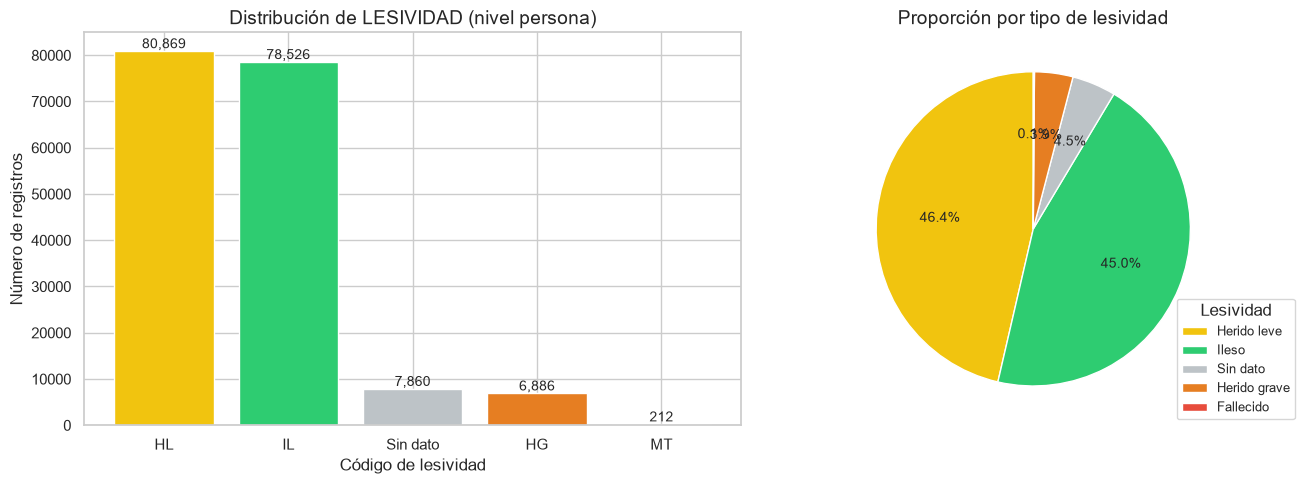

In [67]:
# Gráfico de distribución de LESIVIDAD
lesividad_plot = df['LESIVIDAD'].fillna('Sin dato')
lesividad_dist = lesividad_plot.value_counts()
order = lesividad_dist.index.tolist()
colores_orden = [COLORES_LESIVIDAD_EXT.get(c, COLOR_SIN_DATO) for c in order]
labels_map = {'IL': 'Ileso', 'HL': 'Herido leve', 'HG': 'Herido grave',
              'MT': 'Fallecido', 'Sin dato': 'Sin dato'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(order, lesividad_dist.values, color=colores_orden, edgecolor='white')
axes[0].set_title('Distribución de LESIVIDAD (nivel persona)', fontsize=14)
axes[0].set_xlabel('Código de lesividad')
axes[0].set_ylabel('Número de registros')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}',
                     (p.get_x() + p.get_width() / 2, p.get_height()),
                     ha='center', va='bottom', fontsize=10)

labels_pie = [labels_map[c] for c in order]
wedges, _, _ = axes[1].pie(lesividad_dist.values, labels=None, autopct='%1.1f%%',
                            colors=colores_orden, startangle=90, textprops={'fontsize': 10})
axes[1].set_title('Proporción por tipo de lesividad', fontsize=14)
axes[1].legend(wedges, labels_pie, title='Lesividad', loc='lower left',
               bbox_to_anchor=(0.85, 0), fontsize=9)

plt.tight_layout()
plt.savefig('../figures/01_distribucion_lesividad.png', dpi=150)
plt.show()

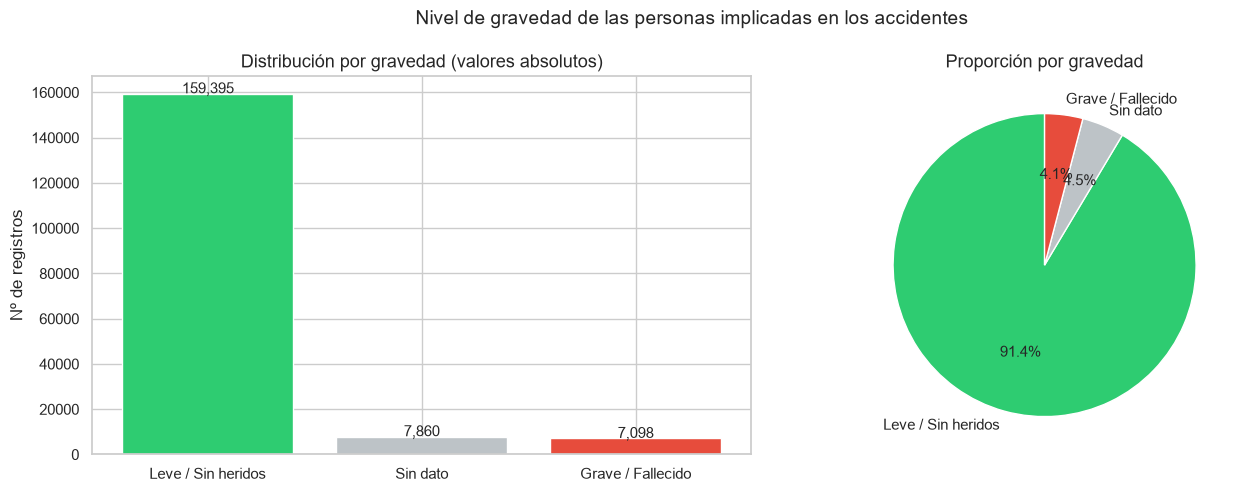

Desequilibrio de clases — ratio: 22.5:1
Graves + Fallecidos: 7,098 (4.1%)


In [68]:
# Clasificación binaria: Leve/Sin heridos vs Grave/Fallecido
gravedad_labels = df['LESIVIDAD'].map({
    'IL': 'Leve / Sin heridos', 'HL': 'Leve / Sin heridos',
    'HG': 'Grave / Fallecido',  'MT': 'Grave / Fallecido'
}).fillna('Sin dato')

gravedad_counts = gravedad_labels.value_counts()
ratio = gravedad_counts.get('Leve / Sin heridos', 1) / gravedad_counts.get('Grave / Fallecido', 1)

COLOR_MAP_GRAV = {
    'Leve / Sin heridos': '#2ecc71',
    'Grave / Fallecido':  '#e74c3c',
    'Sin dato':           COLOR_SIN_DATO
}
colors_grav = [COLOR_MAP_GRAV[k] for k in gravedad_counts.index]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(gravedad_counts.index, gravedad_counts.values, color=colors_grav, edgecolor='white')
axes[0].set_title('Distribución por gravedad (valores absolutos)', fontsize=13)
axes[0].set_ylabel('Nº de registros')
for bar, val in zip(axes[0].patches, gravedad_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f'{val:,}', ha='center', fontsize=11)

axes[1].pie(gravedad_counts.values, labels=gravedad_counts.index,
            autopct='%1.1f%%', colors=colors_grav, startangle=90, textprops={'fontsize': 11})
axes[1].set_title('Proporción por gravedad', fontsize=13)

plt.suptitle('Nivel de gravedad de las personas implicadas en los accidentes', fontsize=14)
plt.tight_layout()
plt.savefig('../figures/01b_gravedad_binaria.png', dpi=150)
plt.show()

print(f'Desequilibrio de clases — ratio: {ratio:.1f}:1')
print(f'Graves + Fallecidos: {gravedad_counts.get("Grave / Fallecido", 0):,} '
      f'({gravedad_counts.get("Grave / Fallecido", 0)/gravedad_counts.sum()*100:.1f}%)')

### 📝 Resumen — Sección 2

> - La categoría más frecuente es HL (herido leve) con 80.869 registros (46,4%), seguida de IL (ileso) con 78.526 (45%).
> - Las personas con heridas graves o fallecidas representan el **4,3% del total**, lo que supone un notable **desequilibrio de clases** (ratio ~22.5:1) que deberá abordarse en la fase de modelización.
> - Se utilizará **clasificación binaria** una vez se hayan limpiado los datos: Accidente grave/Accidente leve, ya que el objetivo es predecir la probabilidad de consecuencias graves dadas las condiciones del accidente.

---
## 3. Perfil de los implicados

El perfil de las personas implicadas en el accidente (su rol, sexo, edad y tipo de vehículo) puede estar relacionado con la gravedad de las consecuencias. Se analiza la distribución de cada variable y su relación con `LESIVIDAD` a nivel persona.

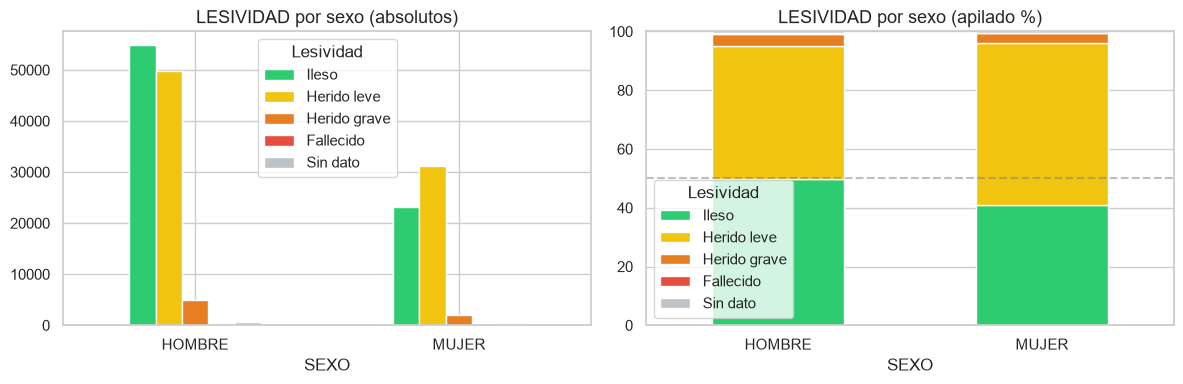

In [69]:
# LESIVIDAD por sexo
df_sexo = df[df['SEXO'].isin(['HOMBRE', 'MUJER'])].copy()
df_sexo['LESIVIDAD'] = df_sexo['LESIVIDAD'].fillna('Sin dato')

lesividad_sexo = (df_sexo.groupby(['SEXO', 'LESIVIDAD']).size()
                  .unstack(fill_value=0)
                  .reindex(columns=ORDEN_LESIVIDAD_EXT, fill_value=0))
lesividad_sexo_pct = lesividad_sexo.div(lesividad_sexo.sum(axis=1), axis=0) * 100

colores = [COLORES_LESIVIDAD_EXT[c] for c in ORDEN_LESIVIDAD_EXT]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

lesividad_sexo.plot(kind='bar', ax=axes[0], color=colores, edgecolor='white')
axes[0].set_title('LESIVIDAD por sexo (absolutos)', fontsize=13)
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Lesividad', labels=LABELS_LESIVIDAD_EXT)

lesividad_sexo_pct.plot(kind='bar', stacked=True, ax=axes[1], color=colores, edgecolor='white')
axes[1].set_title('LESIVIDAD por sexo (apilado %)', fontsize=13)
axes[1].tick_params(axis='x', rotation=0)
axes[1].set_ylim(0, 100)
axes[1].axhline(50, color='grey', linestyle='--', alpha=0.5, label='_nolegend_')
axes[1].legend(title='Lesividad', labels=LABELS_LESIVIDAD_EXT)

plt.tight_layout()
plt.savefig('../figures/10b_lesividad_por_sexo.png', dpi=150)
plt.show()

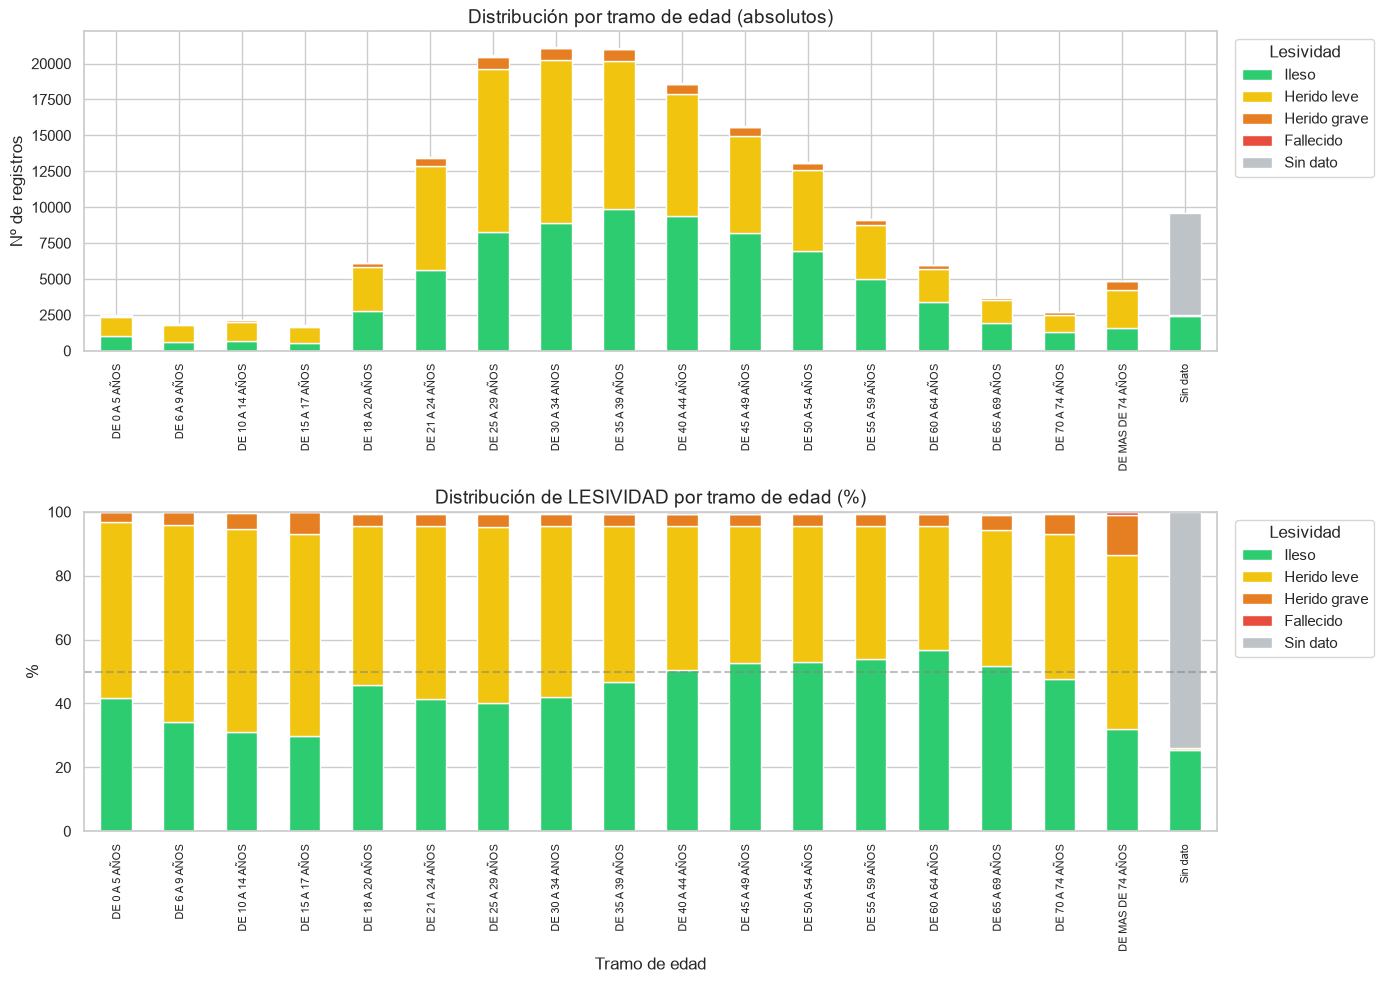

In [70]:
# Distribución por tramo de edad y LESIVIDAD
orden_edad = [
    'DE 0 A 5 AÑOS', 'DE 6 A 9 AÑOS', 'DE 10 A 14 AÑOS', 'DE 15 A 17 AÑOS',
    'DE 18 A 20 AÑOS', 'DE 21 A 24 AÑOS', 'DE 25 A 29 AÑOS', 'DE 30 A 34 ANOS',
    'DE 35 A 39 AÑOS', 'DE 40 A 44 AÑOS', 'DE 45 A 49 AÑOS', 'DE 50 A 54 AÑOS',
    'DE 55 A 59 AÑOS', 'DE 60 A 64 AÑOS', 'DE 65 A 69 AÑOS', 'DE 70 A 74 AÑOS',
    'DE MAS DE 74 AÑOS', 'Sin dato'
]

df_edad = df.copy()
df_edad['LESIVIDAD']  = df_edad['LESIVIDAD'].fillna('Sin dato')
df_edad['Tramo Edad'] = df_edad['Tramo Edad'].fillna('Sin dato')

lesividad_edad = (df_edad.groupby(['Tramo Edad', 'LESIVIDAD']).size()
                         .unstack(fill_value=0)
                         .reindex(index=orden_edad, columns=ORDEN_LESIVIDAD_EXT, fill_value=0))
lesividad_edad_pct = lesividad_edad.div(lesividad_edad.sum(axis=1), axis=0) * 100

colores = [COLORES_LESIVIDAD_EXT[c] for c in ORDEN_LESIVIDAD_EXT]

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

lesividad_edad.plot(kind='bar', stacked=True, ax=axes[0], color=colores, edgecolor='white')
axes[0].set_title('Distribución por tramo de edad (absolutos)', fontsize=14)
axes[0].set_xlabel(''); axes[0].set_ylabel('Nº de registros')
axes[0].legend(title='Lesividad', labels=LABELS_LESIVIDAD_EXT,
               bbox_to_anchor=(1.01, 1), loc='upper left')
axes[0].tick_params(axis='x', rotation=90, labelsize=8)

lesividad_edad_pct.plot(kind='bar', stacked=True, ax=axes[1], color=colores, edgecolor='white')
axes[1].set_title('Distribución de LESIVIDAD por tramo de edad (%)', fontsize=14)
axes[1].set_xlabel('Tramo de edad'); axes[1].set_ylabel('%')
axes[1].set_ylim(0, 100)
axes[1].axhline(50, color='grey', linestyle='--', alpha=0.5, label='_nolegend_')
axes[1].legend(title='Lesividad', labels=LABELS_LESIVIDAD_EXT,
               bbox_to_anchor=(1.01, 1), loc='upper left')
axes[1].tick_params(axis='x', rotation=90, labelsize=8)

plt.tight_layout()
plt.savefig('../figures/11_tramo_edad.png', dpi=150, bbox_inches='tight')
plt.show()

Distribución de LESIVIDAD por tipo de persona (%):
LESIVIDAD       IL    HL    HG   MT  Sin dato
TIPO PERSONA                                 
CONDUCTOR     48.7  41.8   3.2  0.1       6.3
PEATON         2.1  78.0  19.0  0.9       0.0
VIAJERO       46.3  51.8   1.9  0.0       0.0


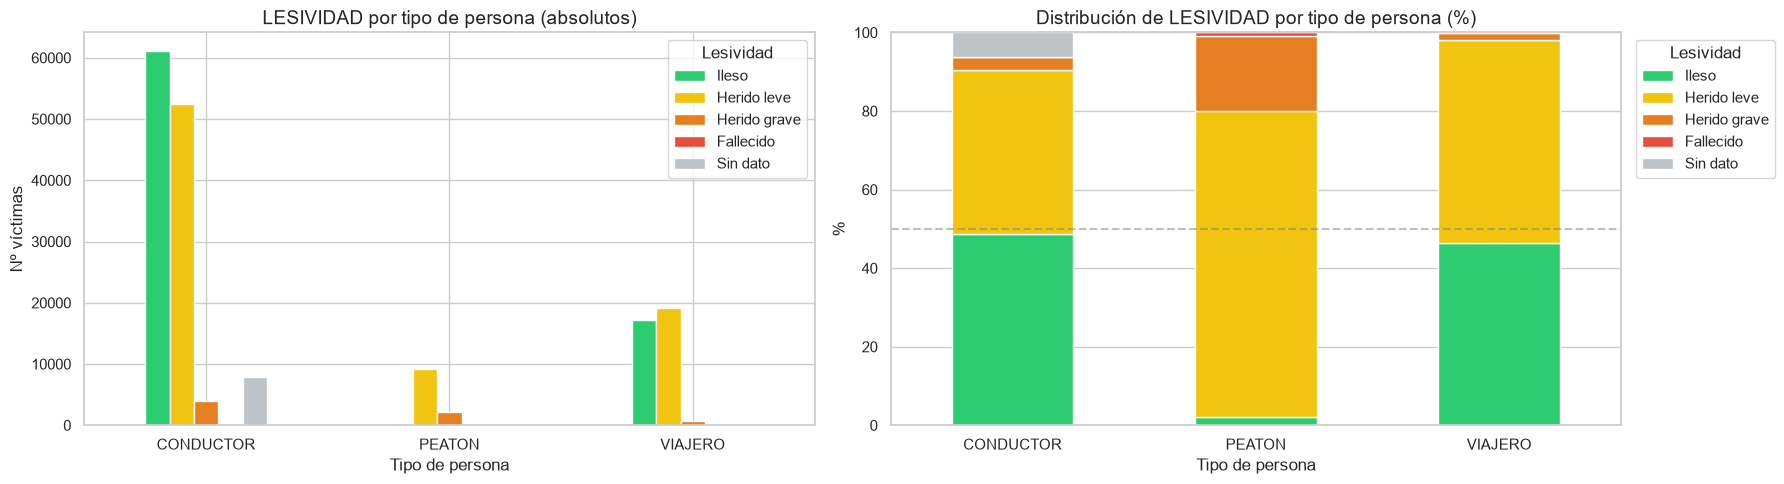

In [71]:
# LESIVIDAD por tipo de persona
df_tipo = df.copy()
df_tipo['LESIVIDAD'] = df_tipo['LESIVIDAD'].fillna('Sin dato')

lesividad_tipo = (df_tipo.groupby(['TIPO PERSONA', 'LESIVIDAD']).size()
                         .unstack(fill_value=0)
                         .reindex(columns=ORDEN_LESIVIDAD_EXT, fill_value=0))
lesividad_tipo_pct = lesividad_tipo.div(lesividad_tipo.sum(axis=1), axis=0) * 100

colores = [COLORES_LESIVIDAD_EXT[c] for c in ORDEN_LESIVIDAD_EXT]

print('Distribución de LESIVIDAD por tipo de persona (%):')
print(lesividad_tipo_pct.round(1))

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

lesividad_tipo.plot(kind='bar', ax=axes[0], color=colores, edgecolor='white')
axes[0].set_title('LESIVIDAD por tipo de persona (absolutos)', fontsize=14)
axes[0].set_xlabel('Tipo de persona'); axes[0].set_ylabel('Nº víctimas')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Lesividad', labels=LABELS_LESIVIDAD_EXT)

lesividad_tipo_pct.plot(kind='bar', stacked=True, ax=axes[1], color=colores, edgecolor='white')
axes[1].set_title('Distribución de LESIVIDAD por tipo de persona (%)', fontsize=14)
axes[1].set_xlabel('Tipo de persona'); axes[1].set_ylabel('%')
axes[1].set_ylim(0, 100)
axes[1].axhline(50, color='grey', linestyle='--', alpha=0.5, label='_nolegend_')
axes[1].legend(title='Lesividad', labels=LABELS_LESIVIDAD_EXT,
               bbox_to_anchor=(1.01, 1), loc='upper left')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('../figures/10c_lesividad_por_tipo_persona.png', dpi=150, bbox_inches='tight')
plt.show()

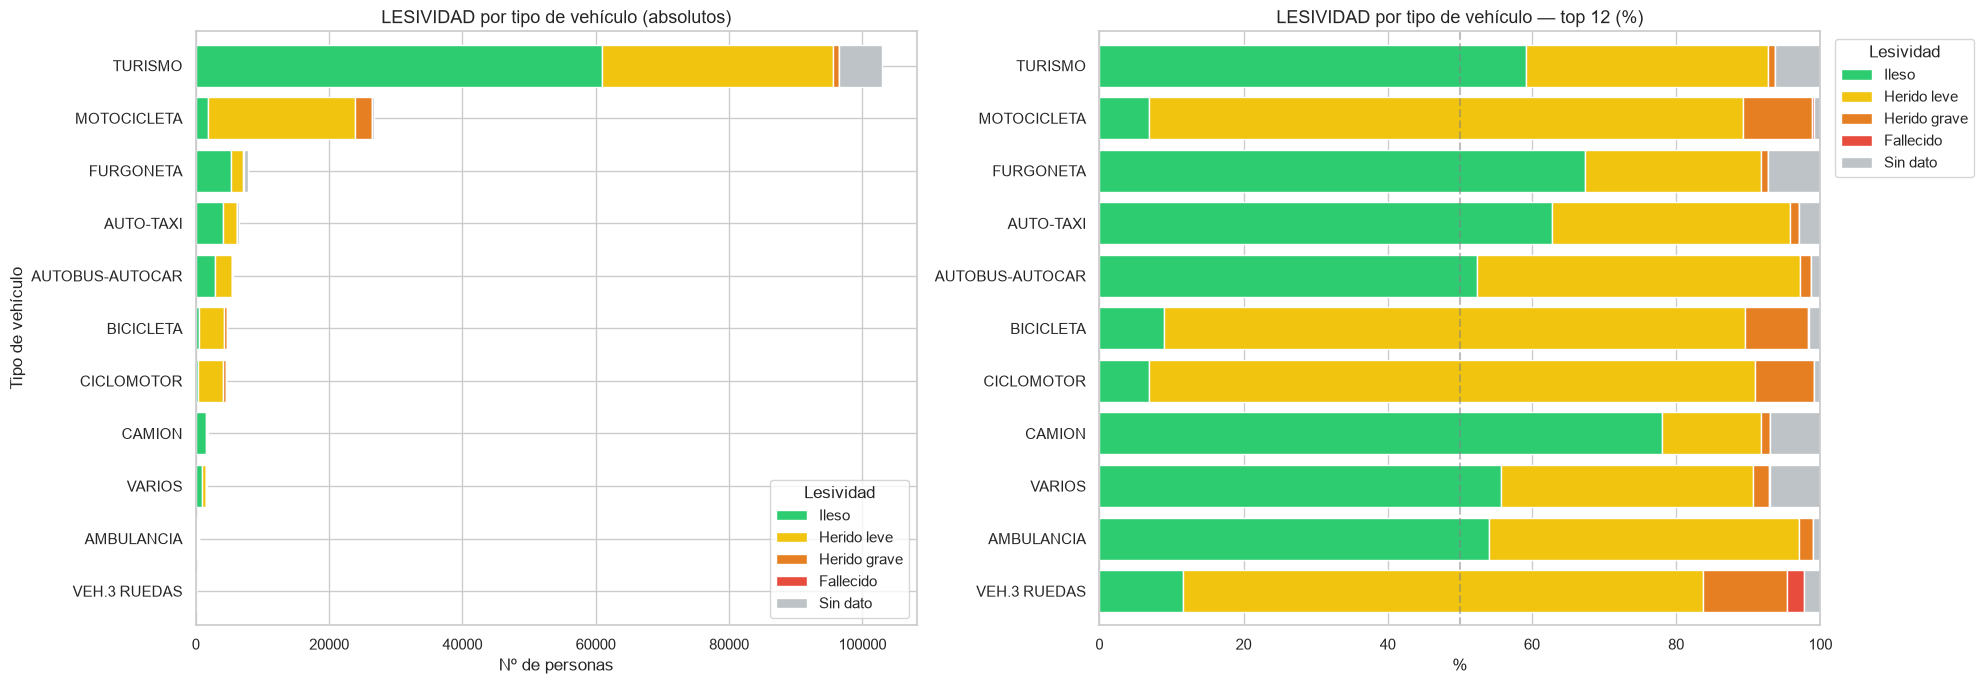

In [72]:
# LESIVIDAD por tipo de vehículo
df_veh_all = df.dropna(subset=['Tipo Vehiculo']).copy()
df_veh_all['LESIVIDAD'] = df_veh_all['LESIVIDAD'].fillna('Sin dato')

colores = [COLORES_LESIVIDAD_EXT[c] for c in ORDEN_LESIVIDAD_EXT]

# Absolutos (todos los vehículos, ordenados por total)
lesividad_veh_abs = (df_veh_all.groupby(['Tipo Vehiculo', 'LESIVIDAD']).size()
                                .unstack(fill_value=0)
                                .reindex(columns=ORDEN_LESIVIDAD_EXT, fill_value=0))
lesividad_veh_abs['TOTAL'] = lesividad_veh_abs.sum(axis=1)
lesividad_veh_abs = lesividad_veh_abs.sort_values('TOTAL', ascending=True).drop(columns='TOTAL')

# % top 12
top_vehiculos = df_veh_all['Tipo Vehiculo'].value_counts().head(12).index
lesividad_vehiculo = (df_veh_all[df_veh_all['Tipo Vehiculo'].isin(top_vehiculos)]
                      .groupby(['Tipo Vehiculo', 'LESIVIDAD']).size()
                      .unstack(fill_value=0)
                      .reindex(columns=ORDEN_LESIVIDAD_EXT, fill_value=0))
lesividad_vehiculo['TOTAL'] = lesividad_vehiculo.sum(axis=1)
lesividad_vehiculo = lesividad_vehiculo.sort_values('TOTAL', ascending=True).drop(columns='TOTAL')
lesividad_vehiculo_pct = lesividad_vehiculo.div(lesividad_vehiculo.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(20, 7))

lesividad_veh_abs.plot(kind='barh', stacked=True, ax=axes[0], color=colores, width=0.8, edgecolor='white')
axes[0].set_title('LESIVIDAD por tipo de vehículo (absolutos)', fontsize=13)
axes[0].set_xlabel('Nº de personas'); axes[0].set_ylabel('Tipo de vehículo')
axes[0].legend(title='Lesividad', labels=LABELS_LESIVIDAD_EXT)

lesividad_vehiculo_pct.plot(kind='barh', stacked=True, ax=axes[1], color=colores, width=0.8, edgecolor='white')
axes[1].set_title('LESIVIDAD por tipo de vehículo — top 12 (%)', fontsize=13)
axes[1].set_xlabel('%'); axes[1].set_xlim(0, 100); axes[1].set_ylabel('')
axes[1].axvline(50, color='grey', linestyle='--', alpha=0.5, label='_nolegend_')
axes[1].legend(title='Lesividad', labels=LABELS_LESIVIDAD_EXT,
               bbox_to_anchor=(1.01, 1), loc='upper left')

plt.tight_layout()
plt.savefig('../figures/13_lesividad_por_vehiculo.png', dpi=150, bbox_inches='tight')
plt.show()

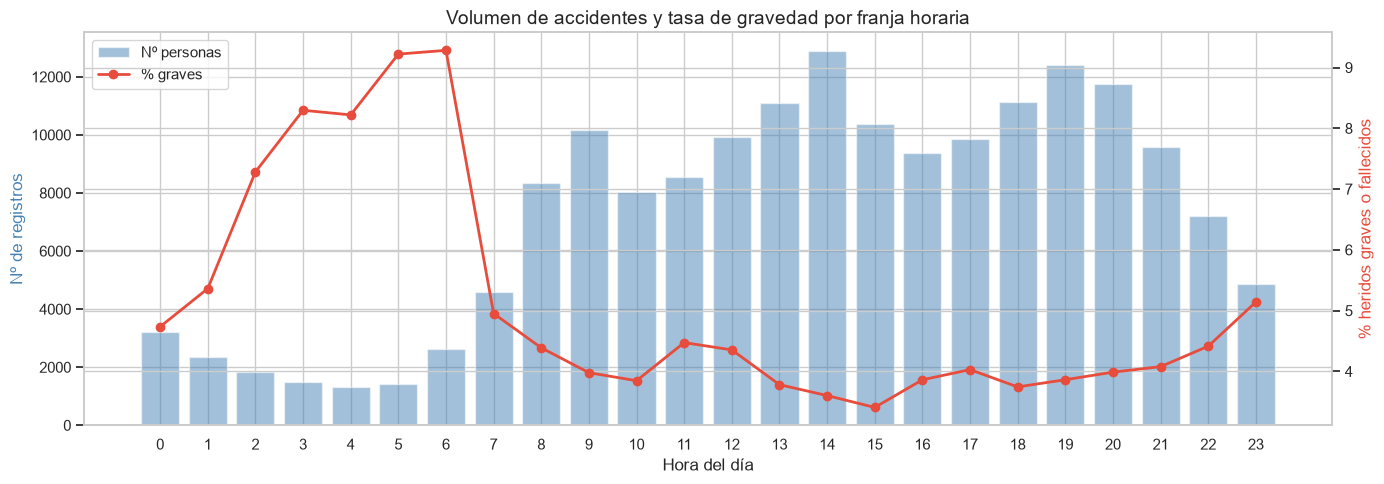

In [73]:
# Volumen de accidentes y tasa de gravedad por franja horaria
df['HORA']      = df['RANGO HORARIO'].str.extract(r'(\d+)').astype(float)
df['GRAVE_tmp'] = df['LESIVIDAD'].isin(['HG', 'MT']).astype(float)
df.loc[df['LESIVIDAD'].isna(), 'GRAVE_tmp'] = float('nan')

accidentes_hora_n = df.groupby('HORA').size()
tasa_grave_hora   = df.groupby('HORA')['GRAVE_tmp'].mean() * 100

df.drop(columns=['HORA', 'GRAVE_tmp'], inplace=True)

fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()

ax1.bar(accidentes_hora_n.index, accidentes_hora_n.values, color='steelblue', alpha=0.5, label='Nº personas')
ax2.plot(tasa_grave_hora.index, tasa_grave_hora.values, color='#e74c3c',
         marker='o', linewidth=2, label='% graves')

ax1.set_xlabel('Hora del día')
ax1.set_ylabel('Nº de registros', color='steelblue')
ax2.set_ylabel('% heridos graves o fallecidos', color='#e74c3c')
ax1.set_title('Volumen de accidentes y tasa de gravedad por franja horaria', fontsize=14)
ax1.set_xticks(range(0, 24))

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.savefig('../figures/14_gravedad_por_hora.png', dpi=150)
plt.show()

### 📝 Resumen — Sección 3

> - El tipo de persona más frecuente son los **conductores**, seguidos de viajeros y peatones. Los **peatones presentan la mayor proporción de heridos graves y fallecidos**, lo que los convierte en el grupo más vulnerable.
> - Los **hombres** representan un mayor volumen de accidentalidad que las mujeres. En términos de gravedad relativa, ambos sexos presentan proporciones similares, aunque los hombres muestran una tasa de HG+MT ligeramente superior.
> - Los tramos de edad con mayor gravedad relativa son los **mayores de 65 años** y los **menores de 18 años**, reflejando mayor vulnerabilidad física en edades extremas. Los tramos de 25-44 años concentran el mayor volumen de accidentes por ser los conductores más activos.
> - Los vehículos con mayor tasa de lesividad grave son las **motocicletas y bicicletas**, mientras que los turismos concentran el mayor volumen absoluto.

---
## 4. Conclusiones y paso siguiente

> - El dataset contiene registros a nivel persona con fuerte desequilibrio de clases (~4% graves).  
> - Los **peatones**, **mayores de 65** y usuarios de **motocicleta/bicicleta** son los perfiles más vulnerables.  
> - Los hombres representan mayor volumen de accidentalidad pero ambos sexos tienen gravedad relativa similar.  

El siguiente paso es **agregar el dataset a nivel accidente** y realizar el EDA orientado al modelo. Ver `02_EDA_accidentes.ipynb`.